In [1]:
## load the 3 swap seqs with their selected SEAM configs
#   peak26256 : 100_k200   |   peak84030 : 300_k300   |   peak27535 : 100_k300
import sys
# force the SEAM/Hippo build of the encoder (matches the K562 ckpt's HeadConfig)
sys.path.insert(0, "/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/"
                   "Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src")
import numpy as np, pandas as pd, h5py, torch
from pathlib import Path
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle

SIT = Path("/grid/koo/home/pmantill/projects/situate/data")
LIB = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib")
ADAPTER = 15      # annotation coords are insert[15:215]; offset into the 230bp insert

peaks = {0: "peak26256", 1: "peak84030", 2: "peak27535_Reversed"}
   # situate row -> peak (config already baked into the foreg
   # round artifact)
wt_seqs, labels = {}, {}
for i, peak in peaks.items():
    with h5py.File(LIB / f"{peak}.h5") as f:
        wt_seqs[i] = f.attrs["wt_seq_str"]        # 230bp WT insert string
        labels[i] = float(f.attrs["mean_value"])  # measured K562 log2FC

with h5py.File(SIT / "mcs_k562/attr.h5") as f:
    fg = f["attr"][:3]            # (3,4,200) projected foreground (what was annotated)
    preds = f["predictions"][:3]  # WT model pred
names = (SIT / "mcs_k562/names.txt").read_text().splitlines()[:3]


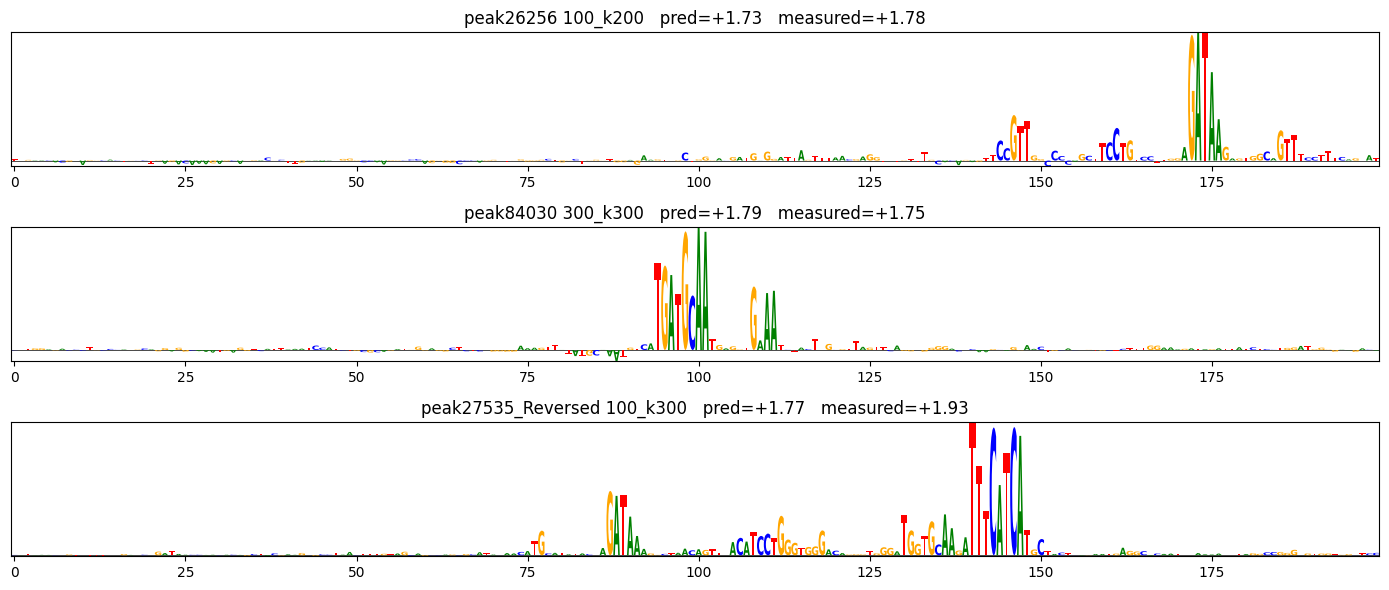

In [2]:
# show the three foreground logos with pred + measured label in the title
import logomaker, matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(14, 6))
for ax, i in zip(axes, range(3)):
    logomaker.Logo(pd.DataFrame(fg[i].T, columns=list("ACGT")), ax=ax)
    ax.set_title(f"{names[i]}   pred={preds[i]:+.2f}   measured={labels[i]:+.2f}")
    ax.set_yticks([])
plt.tight_layout()


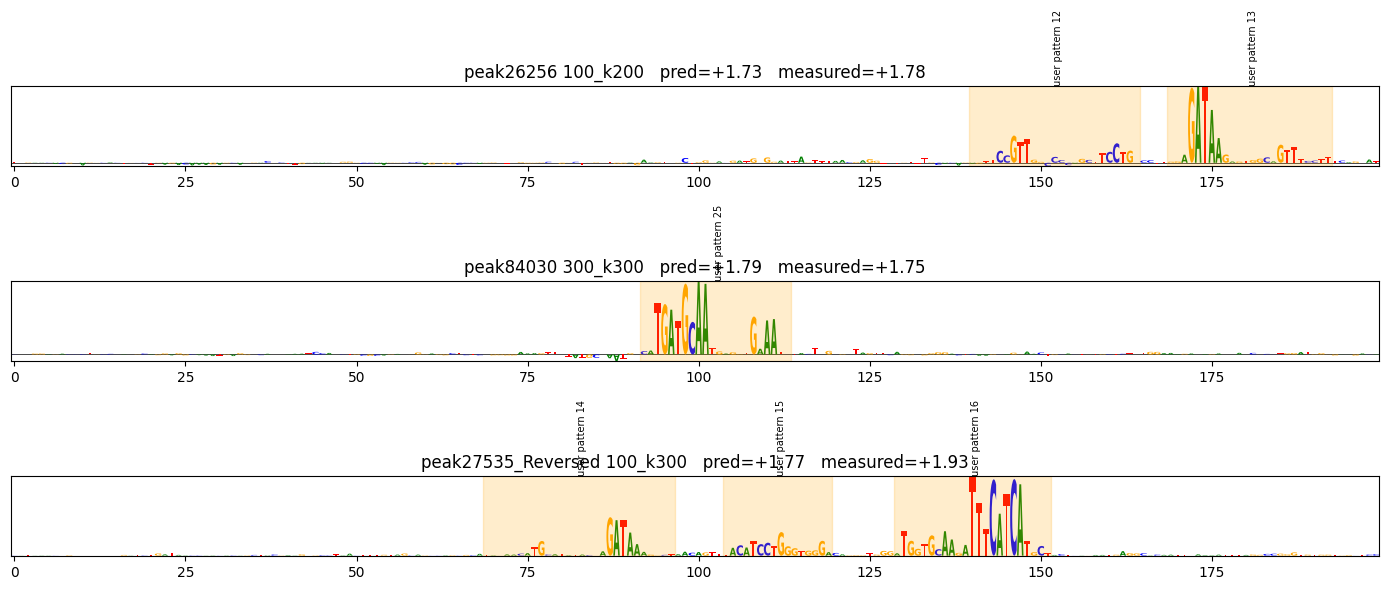

In [3]:
# load manual annotations from situate (single_seq SEAM keys, live) and show logo annotations
sit = pd.read_csv("/grid/koo/home/pmantill/projects/situate/edits.csv")
motifs = {}                                                      # annotated motifs, var-region coords [0,200)
for i, peak in peaks.items():
    g = sit[sit.sequence_name == f"SEAM:K562:{peak}:foreground_scaled"]
    motifs[i] = list(zip(g.start.astype(int), g.end.astype(int), g.motif_name))

fig, axes = plt.subplots(3, 1, figsize=(14, 6))
for ax, i in zip(axes, range(3)):
    logomaker.Logo(pd.DataFrame(fg[i].T, columns=list("ACGT")), ax=ax)
    for s, e, m in motifs[i]:
        ax.axvspan(s - 0.5, e - 0.5, color="orange", alpha=0.2)
        ax.text((s + e) / 2, ax.get_ylim()[1], m, ha="center", va="bottom", fontsize=7, rotation=90)
    ax.set_title(f"{names[i]}   pred={preds[i]:+.2f}   measured={labels[i]:+.2f}")
    ax.set_yticks([])
plt.tight_layout()


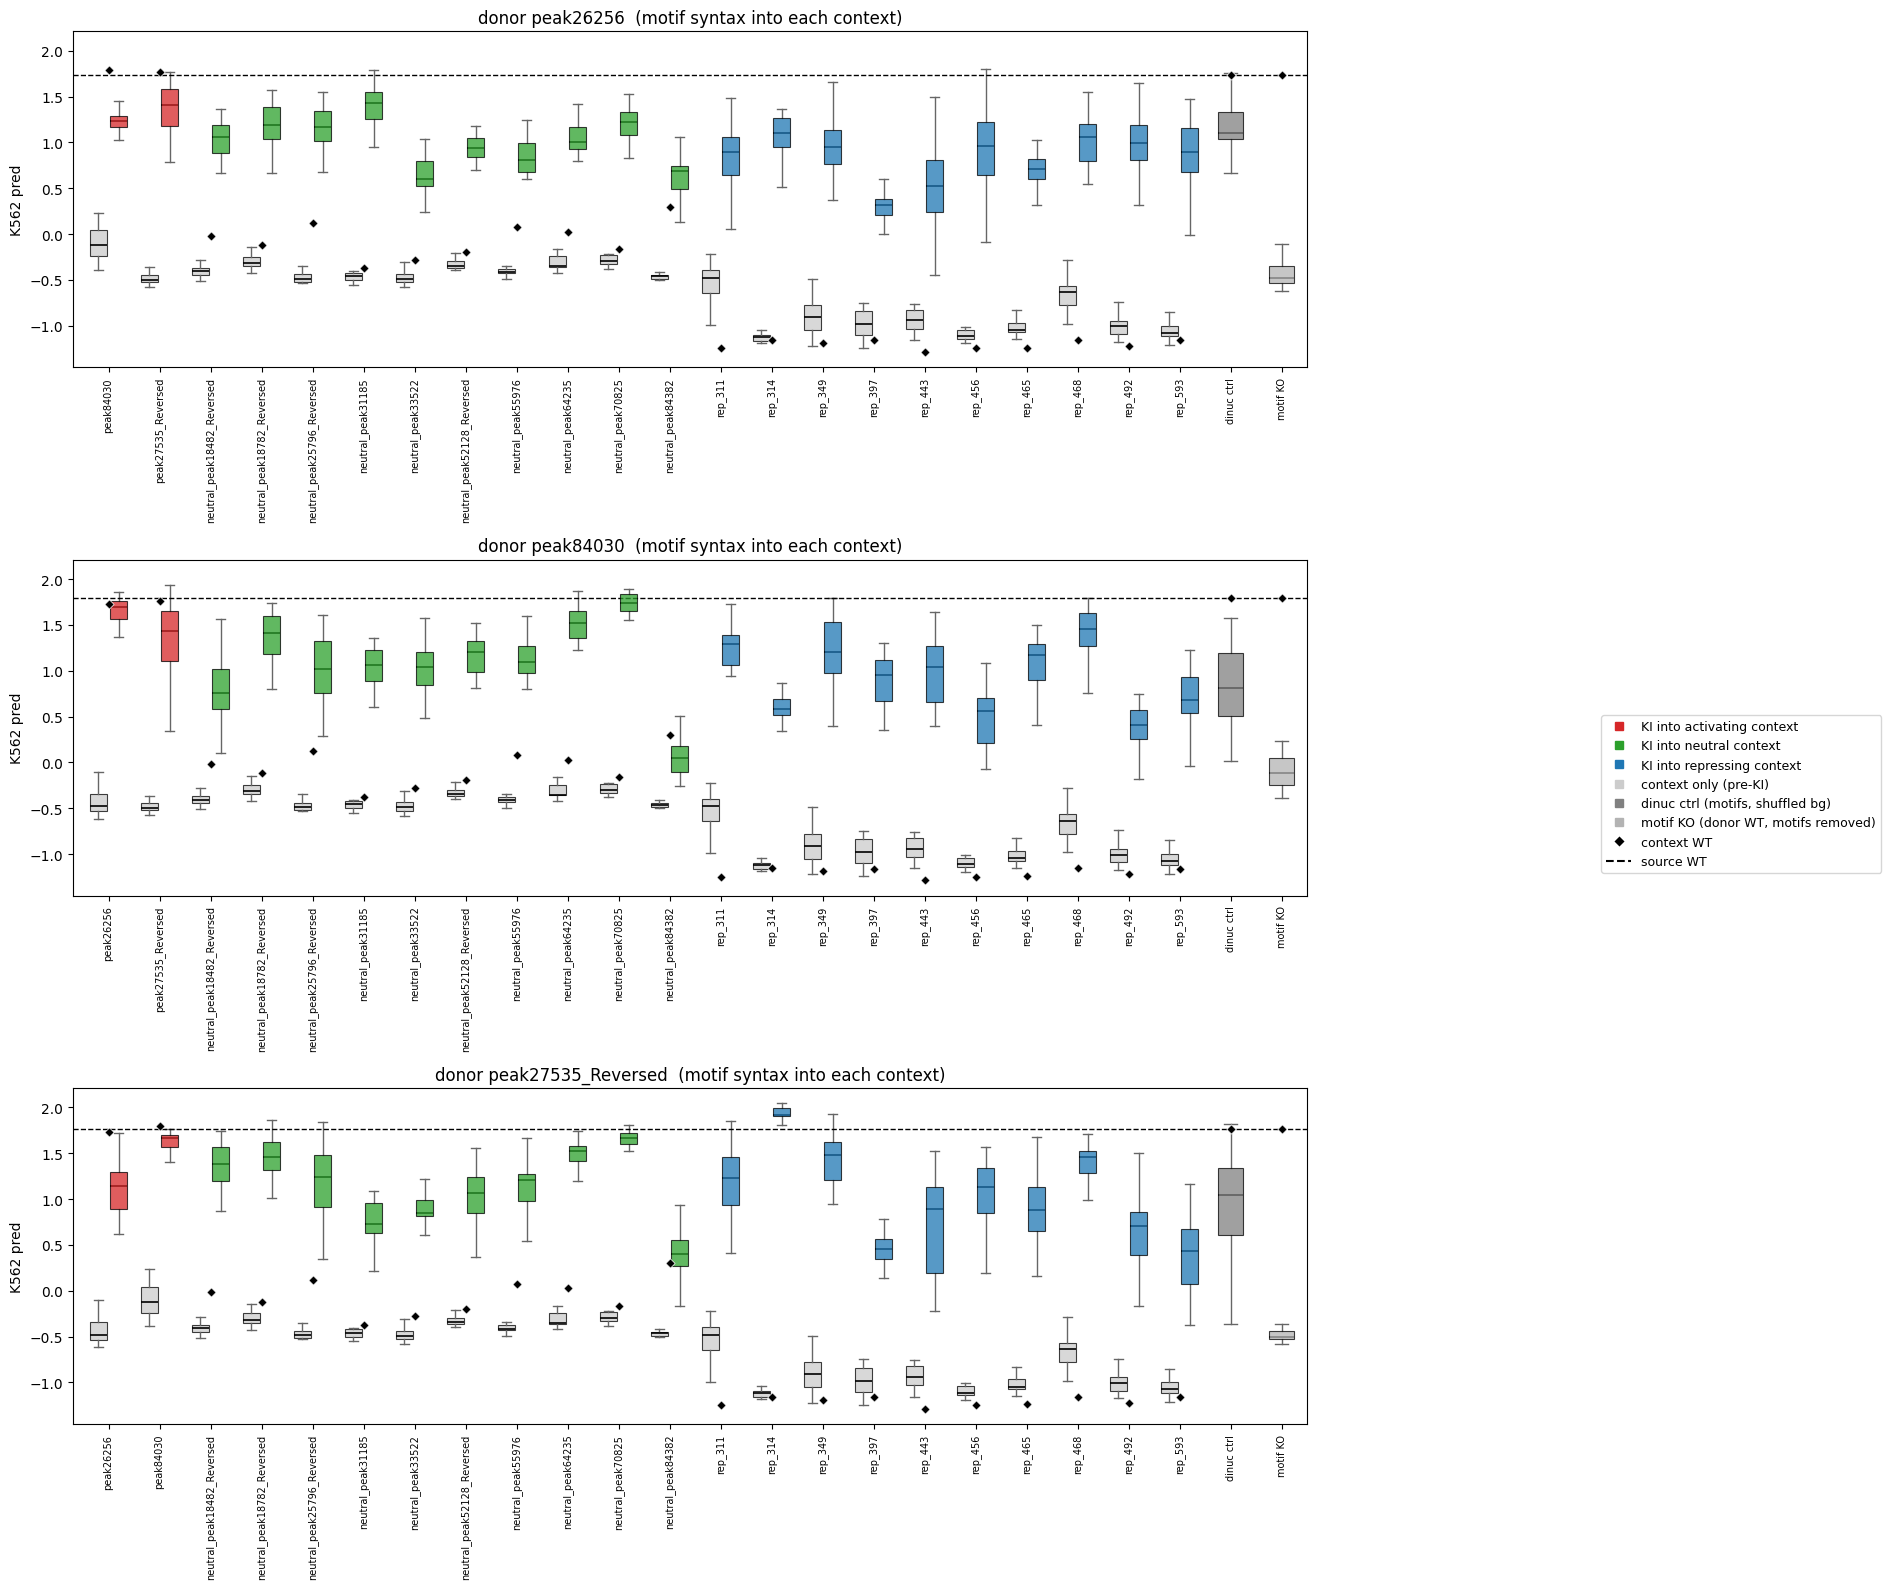

In [4]:
# create swap library: donor motif-syntax (WT motif segments) -> acceptor neutralized context, score, plot
N = 20
CKPT = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
from alphagenome_encoder_ft import EncoderMPRAModel
model = EncoderMPRAModel.from_checkpoint(CKPT, device="cuda").eval()
cfg = torch.load(CKPT, map_location="cpu", weights_only=False)["construct_config"]
suffix = one_hot_encode(cfg["promoter_seq"] + cfg["barcode_seq"]).float()  # (4,51) promoter+barcode

@torch.no_grad()
def score(ohe):                                       # (B,4,230) -> (B,) K562 pred
    out = []
    for k in range(0, len(ohe), 512):
        b = ohe[k:k + 512]
        x = torch.cat([b, suffix.expand(len(b), -1, -1)], 2)
        out.append(model(x.transpose(1, 2).cuda()).cpu().numpy())
    return np.concatenate(out)

# ALL annotations from a SINGLE source: situate/edits.csv, keyed SEAM:K562:{name}:foreground_scaled.
# WT seqs by class: high = 3 designed peaks (mutagenesis_lib WT, from cell 1); low = repressing reps (jointlib);
# neutral = neutral_* (K562 test set). Spans are var-region coords [0,200) -> +ADAPTER into the 230bp insert.
libj = pd.read_pickle("/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConSwap_mpra/"
                      "SEAM_jointlib900/libraries/jointlib900_library.pkl")["df"]
libj = libj[libj.cell_type == "K562"].set_index("seq_idx")
_mp = pd.read_csv("/grid/koo/home/pmantill/projects/SEAM_validate/data/mpra/K562_averaged.tsv", sep="\t")
seqmap = dict(zip(_mp.seq_id.astype(str).str.rstrip(":"), _mp.seq))
sit = pd.read_csv("/grid/koo/home/pmantill/projects/situate/edits.csv")
spans = {k: [(int(s) + ADAPTER, int(e) + ADAPTER) for s, e in zip(g.start, g.end)]
         for k, g in sit.groupby("sequence_name")}
FG = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/foregrounds")

seq_str = dict(wt_seqs)                                  # high WT (rows 0-2) from cell 1
all_names = list(peaks.values())                        # peak26256 / peak84030 / peak27535_Reversed
high = list(peaks)                                      # [0, 1, 2]
mot = {i: spans.get(f"SEAM:K562:{peaks[i]}:foreground_scaled", []) for i in high}
low, neutral = [], []
for name in sorted(d.name for d in FG.iterdir() if d.name.startswith("rep_")):    # repressing reps -> WT from jointlib
    key = f"SEAM:K562:{name}:foreground_scaled"
    if not spans.get(key):
        continue
    i = len(all_names); seq_str[i] = libj.loc[int(name[len("rep_"):]), "sequence"]
    mot[i] = spans[key]; all_names.append(name); low.append(i)
for name in sorted(d.name for d in FG.iterdir() if d.name.startswith("neutral_")):  # neutral -> WT from test set
    key = f"SEAM:K562:{name}:foreground_scaled"
    if not spans.get(key):
        continue
    i = len(all_names); seq_str[i] = seqmap[name[len("neutral_"):].rstrip(":")]
    mot[i] = spans[key]; all_names.append(name); neutral.append(i)
allseqs = high + neutral + low                          # every annotated seq, class order (neutral middle)

def carrier(i):   # n donor backgrounds for the dinuc ctrl: dinuc-shuffled, donor motifs restored (motifs intact, rest neutralized)
    wt = one_hot_encode(seq_str[i]).float()
    blk = dinucleotide_shuffle(wt.unsqueeze(0), n=N, random_state=0)[0]
    for s, e in mot[i]:
        blk[:, :, s:e] = wt[:, s:e]
    return blk

def context(i):   # n acceptor contexts: WT flanks kept, own motifs neutralized (dinuc-shuffled at motif positions)
    wt = one_hot_encode(seq_str[i]).float()
    shuf = dinucleotide_shuffle(wt.unsqueeze(0), n=N, random_state=1)[0]
    ctx = wt.unsqueeze(0).repeat(N, 1, 1).clone()
    for s, e in mot[i]:
        ctx[:, :, s:e] = shuf[:, :, s:e]
    return ctx

def inject(d, ctx):   # overwrite donor d's motif segments (single fixed WT syntax) into each of the N target contexts
    wt = one_hot_encode(seq_str[d]).float()
    out = ctx.clone()
    for s, e in mot[d]:
        out[:, :, s:e] = wt[:, s:e]
    return out

# ALL-BY-ALL: every donor's motif syntax injected into every other seq's N neutralized contexts.
# swap[d][t] = (N,) donor d syntax in target t's contexts. ctrl[d] = dinuc ctrl (syntax, no context);
# pre[i] = context only (own motifs neutralized, no donor); pre[d] doubles as donor d's motif-KO ctrl.
ctx_cache = {i: context(i) for i in allseqs}                  # neutralized acceptor contexts, computed once
swap = {d: {} for d in allseqs}
ctrl = {}
for d in allseqs:
    ctrl[d] = score(carrier(d))
    for t in allseqs:
        if t != d:
            swap[d][t] = score(inject(d, ctx_cache[t]))
pre = {i: score(ctx_cache[i]) for i in allseqs}
wt_all = {i: float(p) for i, p in enumerate(score(torch.stack(   # original WT K562 pred per seq
    [one_hot_encode(seq_str[i]).float() for i in range(len(all_names))])))}

RED, BLUE, GREEN = "#d62728", "#1f77b4", "#2ca02c"   # activating (high) | repressing (low) | neutral class

def ctx_color(t):
    return RED if t in high else GREEN if t in neutral else BLUE

# detailed per-donor view for the 3 designed (high) donors; per target a dodged pair: gray context-only box
# (pre-KI) + KI box colored by target context class. two rightmost gray controls: dinuc ctrl + motif KO.
# black diamond = context seq's own WT (donor WT at both controls); dashed line = donor (source) WT.
def draw_boxes(ax, data, positions, width, facecolors, zorder):
    bp = ax.boxplot(data, positions=positions, widths=width, patch_artist=True, showfliers=False,
                    medianprops=dict(color="black", lw=1.2), whiskerprops=dict(color="0.4"),
                    capprops=dict(color="0.4"), boxprops=dict(lw=0.8))
    for patch, fc in zip(bp["boxes"], facecolors):
        patch.set_facecolor(fc); patch.set_alpha(0.75); patch.set_zorder(zorder)
    return bp

fig, axes = plt.subplots(len(high), 1, figsize=(16, 16), sharey=True)
for ax, d in zip(axes, high):
    targets = [t for t in allseqs if t != d]                 # every other seq (high, neutral, low)
    pos = np.arange(len(targets) + 2)
    tpos, cpos = pos[:-2], pos[-2:]                           # target positions | dinuc ctrl, motif-KO ctrl
    ki_fc = [ctx_color(t) for t in targets]
    draw_boxes(ax, [pre[t] for t in targets], tpos - 0.2, 0.34, ["0.8"] * len(targets), 1)   # context only (pre-KI)
    draw_boxes(ax, [swap[d][t] for t in targets], tpos + 0.2, 0.34, ki_fc, 3)                # donor motifs injected (KI)
    draw_boxes(ax, [ctrl[d], pre[d]], cpos, 0.5, ["0.5", "0.7"], 3)                          # dinuc ctrl | motif KO
    ax.scatter(pos, [wt_all[t] for t in targets] + [wt_all[d], wt_all[d]], marker="D", s=22, color="black",
               edgecolor="white", lw=0.5, zorder=5)
    ax.axhline(wt_all[d], color="black", ls="--", lw=1)
    ax.set_xticks(pos)
    ax.set_xticklabels([all_names[t] for t in targets] + ["dinuc ctrl", "motif KO"], rotation=90, ha="center", fontsize=7)
    ax.set_title(f"donor {all_names[d]}  (motif syntax into each context)")
    ax.set_ylabel("K562 pred")

fig.legend(handles=[plt.Line2D([], [], marker="s", color=RED, ls=""),
                    plt.Line2D([], [], marker="s", color=GREEN, ls=""),
                    plt.Line2D([], [], marker="s", color=BLUE, ls=""),
                    plt.Line2D([], [], marker="s", color="0.8", ls=""),
                    plt.Line2D([], [], marker="s", color="0.5", ls=""),
                    plt.Line2D([], [], marker="s", color="0.7", ls=""),
                    plt.Line2D([], [], marker="D", color="black", mec="white", ls=""),
                    plt.Line2D([], [], color="black", ls="--")],
           labels=["KI into activating context", "KI into neutral context", "KI into repressing context",
                   "context only (pre-KI)", "dinuc ctrl (motifs, shuffled bg)", "motif KO (donor WT, motifs removed)",
                   "context WT", "source WT"],
           loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout()
fig.subplots_adjust(right=0.82)


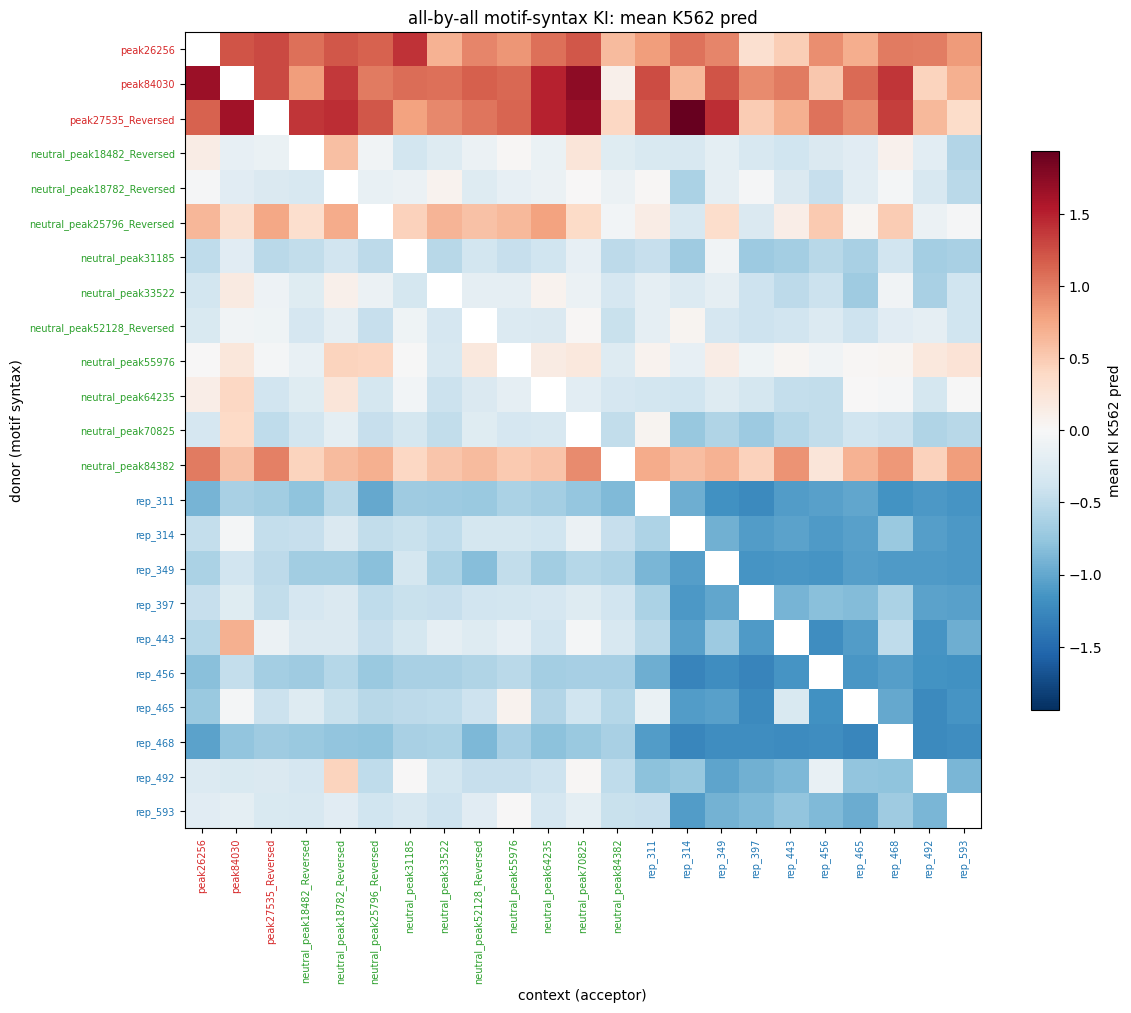

In [5]:
# all-by-all: mean KI K562 pred (over the N reps) for donor d's motif syntax (row) knocked into context t (col).
# diagonal = self (blank). tick labels colored by class: activating=red, neutral=green, repressing=blue.
order = high + neutral + low
M = np.full((len(order), len(order)), np.nan)
for a, d in enumerate(order):
    for b, t in enumerate(order):
        if d != t:
            M[a, b] = swap[d][t].mean()
vmax = np.nanmax(np.abs(M))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="equal")
ax.set_xticks(range(len(order))); ax.set_yticks(range(len(order)))
ax.set_xticklabels([all_names[i] for i in order], rotation=90, fontsize=7)
ax.set_yticklabels([all_names[i] for i in order], fontsize=7)
for tl, i in zip(ax.get_xticklabels(), order): tl.set_color(ctx_color(i))
for tl, i in zip(ax.get_yticklabels(), order): tl.set_color(ctx_color(i))
ax.set_xlabel("context (acceptor)"); ax.set_ylabel("donor (motif syntax)")
ax.set_title("all-by-all motif-syntax KI: mean K562 pred")
fig.colorbar(im, ax=ax, shrink=0.7, label="mean KI K562 pred")
plt.tight_layout()


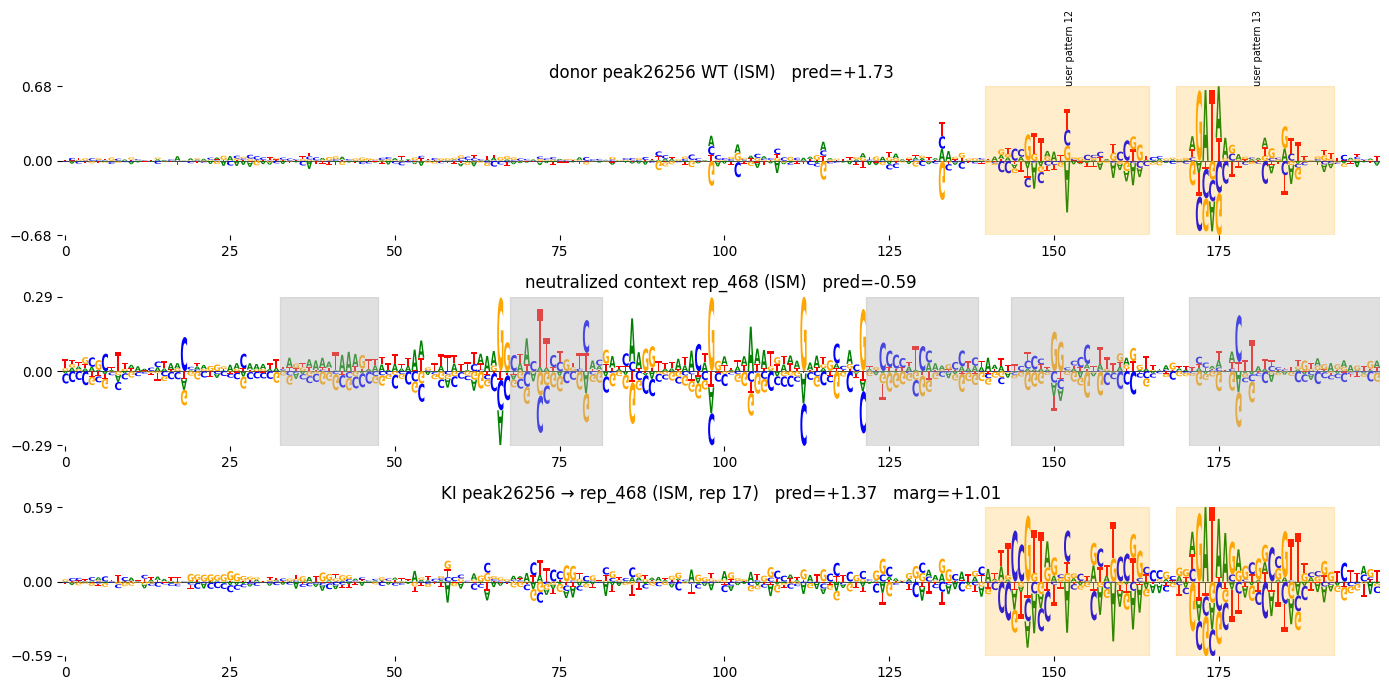

In [6]:
# inspect one knock-in: donor WT (top), neutralized context (mid), KI (bottom).
# all three are saturation-ISM logos (mean-centered across channels = hypothetical), so all obey PROJECT.
# set `sel` 0/1/2 to step donors; context fixed to rep_468, only the KI rep is random each run.
sel = 0
PROJECT = False   # False: full 4-channel saturation ISM (hypothetical). True: project onto the actual base.

d = high[sel]
t = all_names.index("rep_468")                           # fixed context
rng = np.random.default_rng()
r = int(rng.integers(N))                                 # which of the N reps

@torch.no_grad()
def ism(seq):                                            # (4,230) one-hot -> (200,4) ISM over var region
    block = seq.unsqueeze(0).repeat(800, 1, 1).clone()
    for j, p in enumerate(range(ADAPTER, ADAPTER + 200)):
        block[j * 4:j * 4 + 4, :, p] = torch.eye(4)      # rows j*4..+3 = the 4 single-base mutants at p
    m = score(block).reshape(200, 4)
    m -= m.mean(1, keepdims=True)                        # hypothetical: center across channels
    return m * seq[:, ADAPTER:ADAPTER + 200].numpy().T if PROJECT else m

don_seq = one_hot_encode(seq_str[d]).float()             # (4,230) donor WT
ctx_seq = context(t)[r]                                  # (4,230) neutralized acceptor
ki_seq  = inject(d, context(t))[r]                       # (4,230) donor syntax knocked into that context
p_ctx, p_ki = float(score(ctx_seq.unsqueeze(0))[0]), float(score(ki_seq.unsqueeze(0))[0])
marg = float(swap[d][t].mean())                          # KI pred marginalized over the N reps
panels = [(ism(don_seq), f"donor {all_names[d]} WT (ISM)   pred={wt_all[d]:+.2f}"),
          (ism(ctx_seq), f"neutralized context {all_names[t]} (ISM)   pred={p_ctx:+.2f}"),
          (ism(ki_seq),  f"KI {all_names[d]} → {all_names[t]} (ISM, rep {r})   pred={p_ki:+.2f}   marg={marg:+.2f}")]

fig, axes = plt.subplots(3, 1, figsize=(14, 7))
for ax, (mat, ttl) in zip(axes, panels):                # each panel autoscaled on its own y-range
    logomaker.Logo(pd.DataFrame(mat.T if mat.shape[0] == 4 else mat, columns=list("ACGT")), ax=ax)
    ax.set_title(ttl)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_yticks(np.round(np.linspace(*ax.get_ylim(), 3), 2))   # 3 ticks to denote scale
for s, e, m in motifs[d]:                                # donor motifs: annotate WT + mark on KI panel
    axes[0].axvspan(s - 0.5, e - 0.5, color="orange", alpha=0.2)
    axes[0].text((s + e) / 2, axes[0].get_ylim()[1], m, ha="center", va="bottom", fontsize=7, rotation=90)
    axes[2].axvspan(s - 0.5, e - 0.5, color="orange", alpha=0.2)
for s, e in mot[t]:                                      # target's own (neutralized) motif positions
    axes[1].axvspan(s - ADAPTER - 0.5, e - ADAPTER - 0.5, color="0.7", alpha=0.4)
plt.tight_layout()


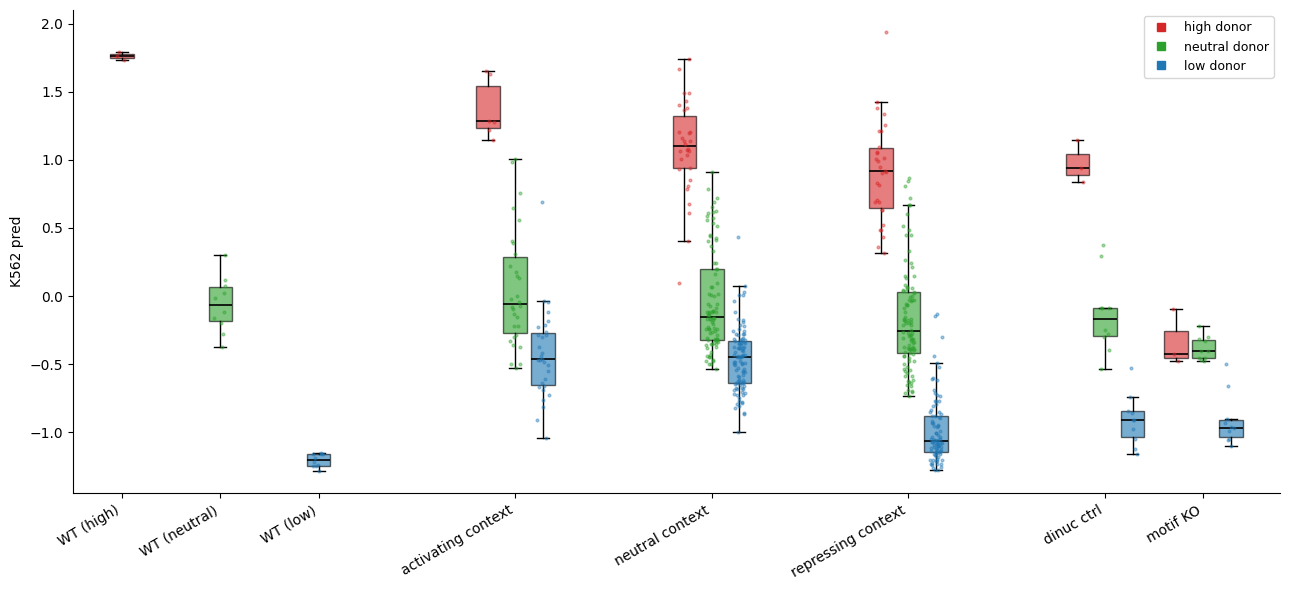

In [12]:
# pooled all-by-all: each context class holds three donor boxes (high=red, neutral=green, low=blue).
# each point = mean over the 20 reps for one (donor, context) pair. order: activating -> neutral -> repressing.
def cls_pool(donors, ctxs):
    return np.array([swap[d][t].mean() for d in donors for t in ctxs if d != t])

CTX = [("activating context", high, 4), ("neutral context", neutral, 6), ("repressing context", low, 8)]
DON = [(high, RED, -0.28), (neutral, GREEN, 0.0), (low, BLUE, 0.28)]   # donor class -> color, dodge offset

boxes = [(np.array([wt_all[i] for i in high]), 0, RED),          # endogenous WT per class
         (np.array([wt_all[i] for i in neutral]), 1, GREEN),
         (np.array([wt_all[i] for i in low]), 2, BLUE)]
for _, ctxs, cx in CTX:
    for donors, dc, off in DON:
        boxes.append((cls_pool(donors, ctxs), cx + off, dc))
for cx, val in [(10, ctrl), (11, pre)]:                          # controls split by donor class (dinuc ctrl | motif KO)
    for donors, dc, off in DON:
        boxes.append((np.array([val[d].mean() for d in donors]), cx + off, dc))
ticks  = [0, 1, 2] + [cx for _, _, cx in CTX] + [10, 11]
labels = ["WT (high)", "WT (neutral)", "WT (low)"] + [c for c, _, _ in CTX] + ["dinuc ctrl", "motif KO"]

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot([b[0] for b in boxes], positions=[b[1] for b in boxes], widths=0.24,
                patch_artist=True, showfliers=False, medianprops=dict(color="black", lw=1.2))
for patch, b in zip(bp["boxes"], boxes):
    patch.set_facecolor(b[2]); patch.set_alpha(0.6)
for data, x, c in boxes:
    ax.scatter(x + rng.uniform(-0.06, 0.06, len(data)), data, s=4, color=c, alpha=0.4, zorder=3)
ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.legend(handles=[plt.Line2D([], [], marker="s", color=RED, ls=""), plt.Line2D([], [], marker="s", color=GREEN, ls=""),
                   plt.Line2D([], [], marker="s", color=BLUE, ls="")],
          labels=["high donor", "neutral donor", "low donor"], loc="best", fontsize=9)
ax.set_ylabel("K562 pred")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

out = Path("/grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/results")
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "swap_experiment.png", dpi=200, bbox_inches="tight")


In [8]:
# save seqs for the flex (C0free) analysis: WT, motif-shuff (own motifs neutralized = context()),
# full-shuff (whole insert dinuc-shuffled), ctx-shuff (motifs intact, context dinuc-shuffled = carrier()),
# chimeric knock-ins, and the WT ISM attribution. Decoded to ACGT strings so the TF flex env loads without
# torch. -> context_feat/flex/data/swap_seqs.npz
BASES = np.array(list("ACGT"))
def to_str(ohe):                                              # (B,4,230) one-hot -> (B,) array of strings
    return np.array(["".join(BASES[r]) for r in ohe.argmax(1).numpy()])

ctx_idx = high + low
motifko_seqs = np.stack([to_str(context(i)) for i in ctx_idx])                  # (n_ctx, N) motifs neutralized
fullshuf_seqs = np.stack([to_str(dinucleotide_shuffle(one_hot_encode(seq_str[i]).float().unsqueeze(0),
                                                      n=N, random_state=2)[0]) for i in ctx_idx])  # (n_ctx, N) whole insert shuffled
ctxshuf_seqs = np.stack([to_str(carrier(i)) for i in high])                     # (n_high, N) motifs intact, context shuffled
attr_wt = np.stack([ism(one_hot_encode(seq_str[i]).float()) for i in ctx_idx])  # (n_ctx, 200, 4) mean-centered WT ISM (var region)
pairs = ([(d, t) for d in high for t in [x for x in high if x != d] + low]     # high donor -> high & low targets
         + [(d, t) for d in low for t in high])                               # low donor -> high targets
chimera_seqs = np.stack([to_str(inject(d, context(t))) for d, t in pairs])      # (n_pairs, N)
mspan_seq   = np.array([i for i in ctx_idx for _ in mot[i]])                    # annotated motif spans (230bp insert coords)
mspan_start = np.array([s for i in ctx_idx for s, e in mot[i]])
mspan_end   = np.array([e for i in ctx_idx for s, e in mot[i]])

flexdir = Path("/grid/koo/home/pmantill/projects/SEAM_validate/context_feat/flex/data")
flexdir.mkdir(parents=True, exist_ok=True)
np.savez(flexdir / "swap_seqs.npz",
         names=np.array(all_names),
         wt=np.array([seq_str[i] for i in range(len(all_names))]),
         high=np.array(high), low=np.array(low),
         motifko=motifko_seqs, fullshuf=fullshuf_seqs, motifko_idx=np.array(ctx_idx),
         ctxshuf=ctxshuf_seqs, ctxshuf_idx=np.array(high),
         attr_wt=attr_wt,
         chimera=chimera_seqs, chimera_donor=np.array([d for d, _ in pairs]),
         chimera_target=np.array([t for _, t in pairs]),
         mspan_seq=mspan_seq, mspan_start=mspan_start, mspan_end=mspan_end)
print("wrote", flexdir / "swap_seqs.npz", "| motifko", motifko_seqs.shape, "| chimera", chimera_seqs.shape, "| ctxshuf", ctxshuf_seqs.shape)

wrote /grid/koo/home/pmantill/projects/SEAM_validate/context_feat/flex/data/swap_seqs.npz | motifko (13, 20) | chimera (66, 20) | ctxshuf (3, 20)


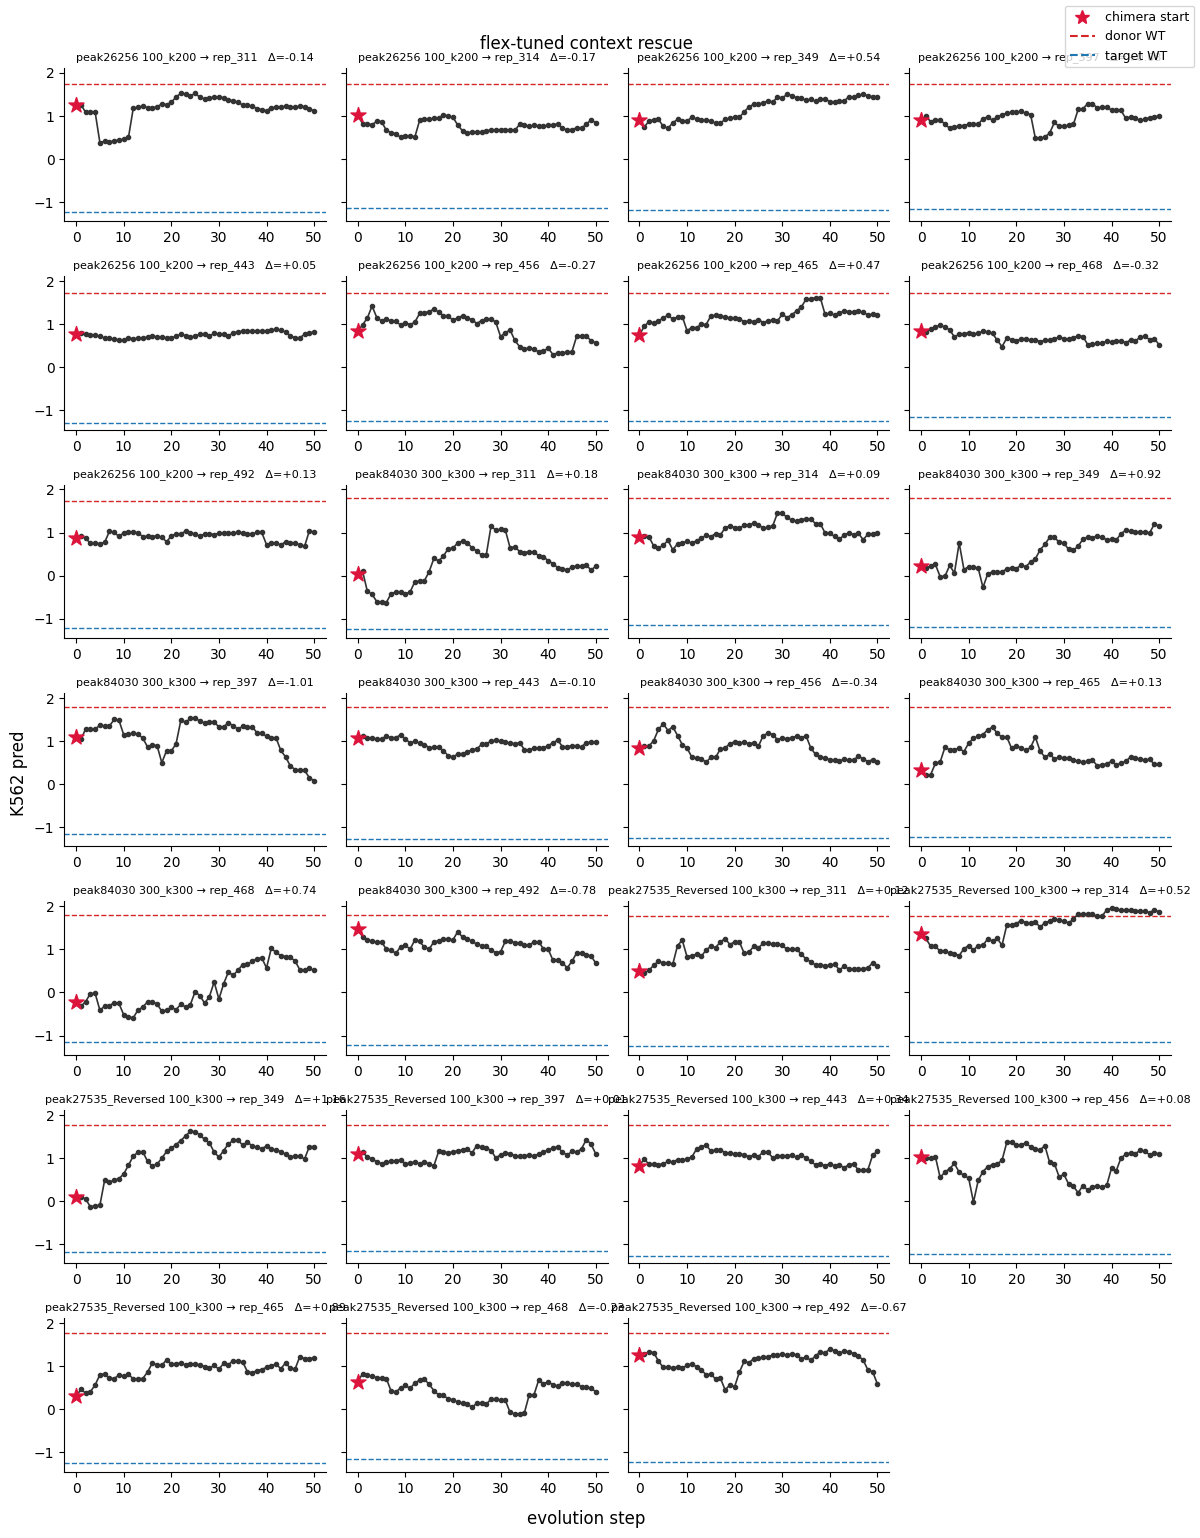

In [9]:
# score K562 along ALL saved flex-evolution trajectories (from swap_rescue.ipynb) -> per chimera, does raising
# context flex rescue activity? one panel per high->low pair; x = evolution step, y = K562 pred.
# star = chimera start; red dashed = donor WT, blue dashed = target WT.
E = np.load("/grid/koo/home/pmantill/projects/SEAM_validate/context_feat/flex/data/evo_traj.npz")
acts = score(torch.stack([one_hot_encode(str(s)).float() for s in E["seqs"]]))   # (M,) K562 pred, evolution order
pair = E["pair"]; uniq = np.unique(pair)

ncol = 4
nrow = int(np.ceil(len(uniq) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 2.2 * nrow), sharey=True, squeeze=False)
for ax, pi in zip(axes.ravel(), uniq):
    m = pair == pi
    d, t = int(E["donor"][pi]), int(E["target"][pi])
    a = acts[m]
    ax.plot(np.arange(len(a)), a, "-o", color="#333333", ms=3, lw=1.2, zorder=3)
    ax.scatter(0, a[0], s=130, marker="*", color="crimson", zorder=5)
    ax.axhline(wt_all[d], color="#d62728", ls="--", lw=1)
    ax.axhline(wt_all[t], color="#1f77b4", ls="--", lw=1)
    ax.set_title(f"{names[d]} → {all_names[t]}   Δ={a[-1] - a[0]:+.2f}", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.ravel()[len(uniq):]:
    ax.axis("off")
fig.legend(handles=[plt.Line2D([], [], marker="*", color="crimson", ls="", ms=10),
                    plt.Line2D([], [], color="#d62728", ls="--"), plt.Line2D([], [], color="#1f77b4", ls="--")],
           labels=["chimera start", "donor WT", "target WT"], loc="upper right", fontsize=9)
fig.supxlabel("evolution step"); fig.supylabel("K562 pred")
fig.suptitle("flex-tuned context rescue")
fig.tight_layout()

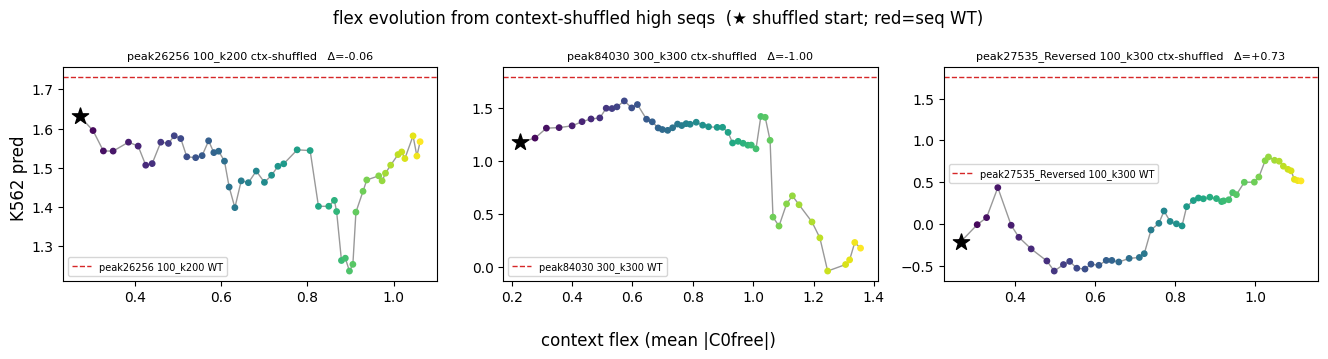

In [10]:
# K562 along the CONTEXT-SHUFFLED high-seq flex-evolution trajectories (from swap_rescue.ipynb): does raising
# context flex alone rebuild activity after the native context is destroyed (motifs kept)? one panel per high
# seq; star = shuffled-context start, path moves right as flex rises. red dashed = that seq's WT activity (goal).
E = np.load("/grid/koo/home/pmantill/projects/SEAM_validate/context_feat/flex/data/evo_ctxshuf.npz")
acts = score(torch.stack([one_hot_encode(str(s)).float() for s in E["seqs"]]))   # (M,) K562 pred, evolution order
pair = E["pair"]; uniq = np.unique(pair)

fig, axes = plt.subplots(1, len(uniq), figsize=(4.5 * len(uniq), 3.5), squeeze=False)
for ax, pi in zip(axes[0], uniq):
    m = pair == pi
    i = int(E["seq_idx"][pi])
    o, a = E["obj"][m], acts[m]
    ax.plot(o, a, "-", color="0.6", lw=1, zorder=1)
    ax.scatter(o, a, c=range(m.sum()), cmap="viridis", s=15, zorder=3)
    ax.scatter(o[0], a[0], s=150, marker="*", color="black", zorder=5)
    ax.axhline(wt_all[i], color="#d62728", ls="--", lw=1, label=f"{names[i]} WT")
    ax.set_title(f"{names[i]} ctx-shuffled   Δ={a[-1] - a[0]:+.2f}", fontsize=8); ax.legend(fontsize=7)
fig.supxlabel("context flex (mean |C0free|)"); fig.supylabel("K562 pred")
fig.suptitle("flex evolution from context-shuffled high seqs  (★ shuffled start; red=seq WT)")
fig.tight_layout()

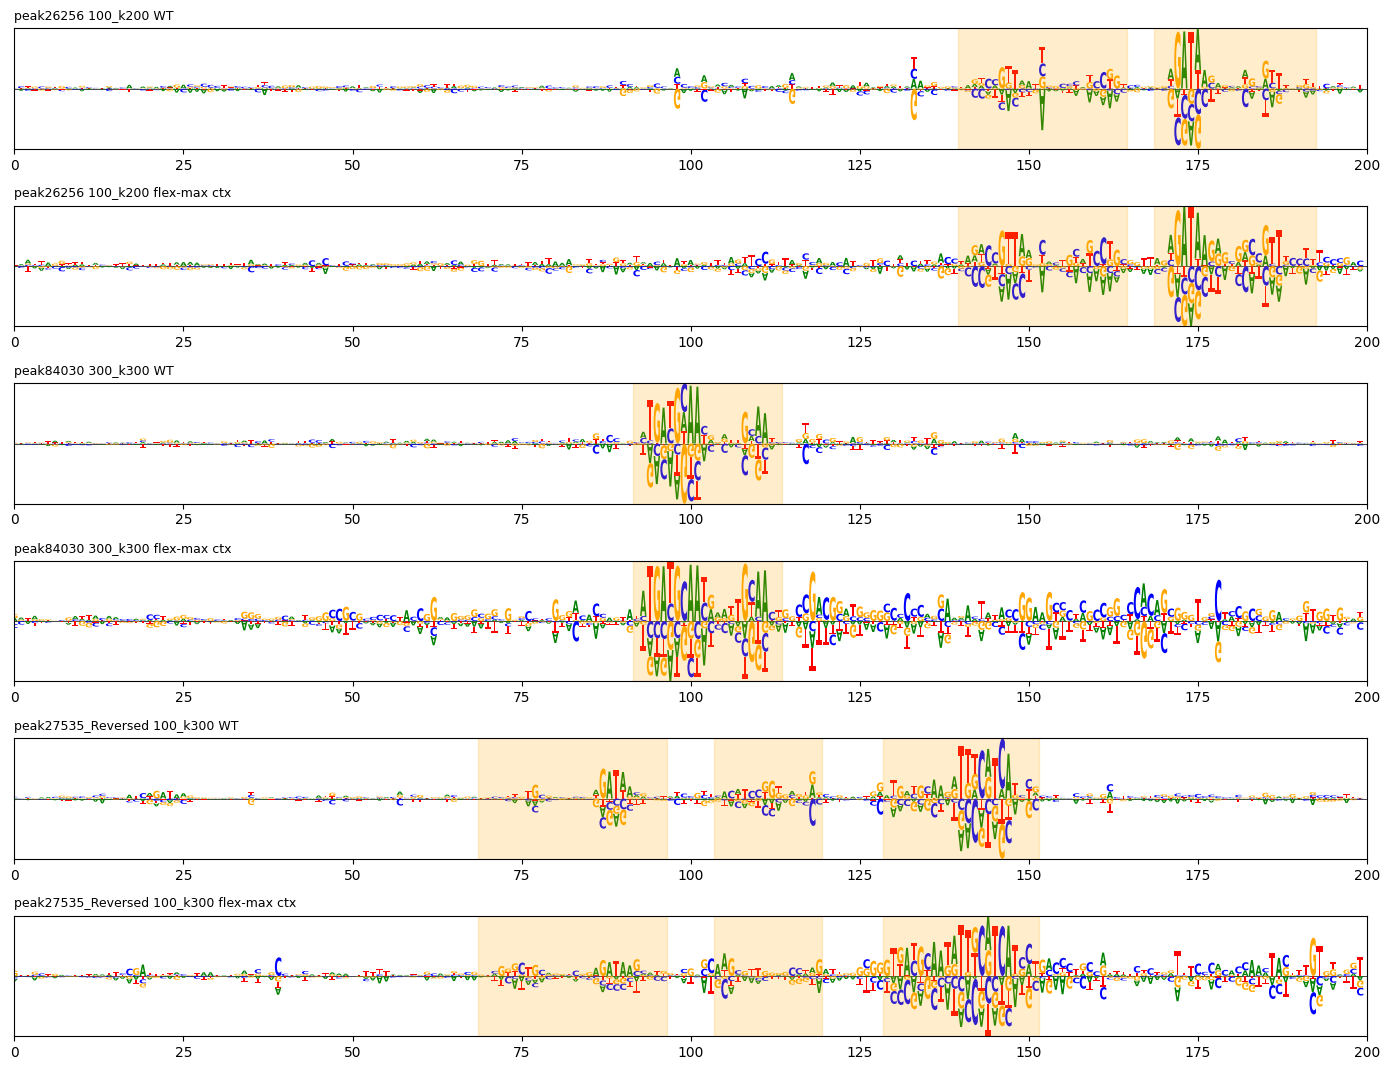

In [11]:
# ISM attribution logos: each high seq WT vs its flex-maxed context-shuffled endpoint (motifs kept, context
# evolved to max flex). Does raising context flex change the motif attributions? annotated motif spans shaded.
E = np.load("/grid/koo/home/pmantill/projects/SEAM_validate/context_feat/flex/data/evo_ctxshuf.npz")
rows = []
for pi in np.unique(E["pair"]):
    i = int(E["seq_idx"][pi])
    end = E["seqs"][np.where(E["pair"] == pi)[0][-1]]                       # last (flex-max) seq of the trajectory
    rows.append((f"{names[i]} WT", ism(one_hot_encode(seq_str[i]).float()), i))
    rows.append((f"{names[i]} flex-max ctx", ism(one_hot_encode(str(end)).float()), i))

fig, axes = plt.subplots(len(rows), 1, figsize=(14, 1.8 * len(rows)))
for ax, (ttl, mat, i) in zip(axes, rows):
    logomaker.Logo(pd.DataFrame(mat, columns=list("ACGT")), ax=ax)
    for s, e in mot[i]:                                                     # motif spans (var-region coords = insert - ADAPTER)
        ax.axvspan(s - ADAPTER - 0.5, e - ADAPTER - 0.5, color="orange", alpha=0.2)
    ax.set_title(ttl, fontsize=9, loc="left"); ax.set_yticks([]); ax.set_xlim(0, 200)
fig.tight_layout()